# 인천공항 이용자수 분석 및 예측
1. https://kosis.kr/search/search.do 접속.
2. 출입국 항구/내외국인/성별 국제이동(연간)검색.
3. 항목(우측사이드): 입국자,출국자,인천공항,내외국인,남여,기간 선택.
4. 피봇테이블설정.</br>
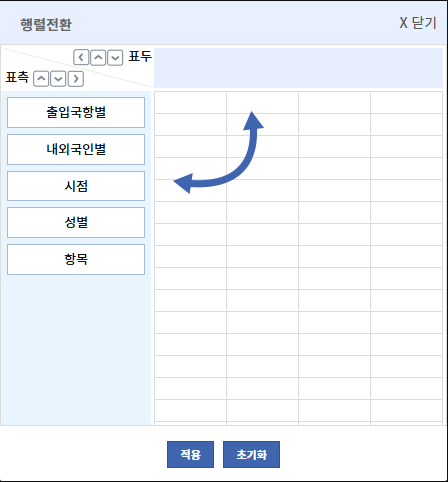

Text(0.2, 0.4, '한글')

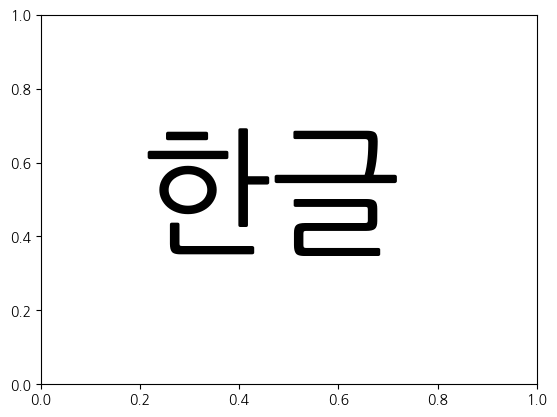

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [4]:
file_path = "dataset/인천공항이용자수20260605.csv"
raw = pd.read_csv(file_path, encoding="EUC-KR") # UTF8
raw.sample(5)

,출입국항별,내외국인별,시점,성별,항목,데이터
7,인천공항,내국인,2002,여자,출국자,136808
187,인천공항,외국인,2023,여자,출국자,130769
164,인천공항,외국인,2018,남자,입국자,229397
191,인천공항,외국인,2024,여자,출국자,136567
94,인천공항,내국인,2024,여자,입국자,117094


In [5]:
# 컬럼명 바꾸기
ex1_data = raw.copy()
# 방법1
# ex1_data.columns = ['airport','type1','year','gender','type2','value']
# 방법2
ex1_data.rename(columns={
    '출입국항별':'airport',
    '내외국인별':'type1',
    '시점':'year',
    '성별':'gender',
    '항목':'type2',
    '데이터':'value'} , inplace=True )
ex1_data.columns

Index(['airport', 'type1', 'year', 'gender', 'type2', 'value'], dtype='object')

In [6]:
# 필터제작
filter1 = ex1_data['type1']=='외국인'
ex2_data = ex1_data[filter1].copy()
ex2_data.head()

,airport,type1,year,gender,type2,value
96,인천공항,외국인,2001,남자,입국자,60699
97,인천공항,외국인,2001,남자,출국자,44548
98,인천공항,외국인,2001,여자,입국자,47963
99,인천공항,외국인,2001,여자,출국자,28348
100,인천공항,외국인,2002,남자,입국자,77745


In [7]:
# 년도별 통계
ex1_total = ex1_data.groupby('year')['value'].sum().reset_index(name='total')
ex1_total #.plot()
# plt.show()

,year,total
0,2001,521210
1,2002,697631
2,2003,747272
3,2004,769912
4,2005,991717
5,2006,996275
6,2007,1012415
7,2008,1080247
8,2009,1009778
9,2010,1019086


In [8]:
filter2_in = ex2_data['type2']=='입국자'
ex2_in =  ex2_data[filter2_in]
filter2_out = ex2_data['type2']=='출국자'
ex2_out =  ex2_data[filter2_out]
ex2_in = ex2_in.groupby('year')['value'].sum().reset_index(name="intotal")
ex2_out = ex2_out.groupby('year')['value'].sum().reset_index(name="outtotal")

<Axes: title={'center': '2015 ~ 2024년 인천공항 입국 외국인 차트'}>

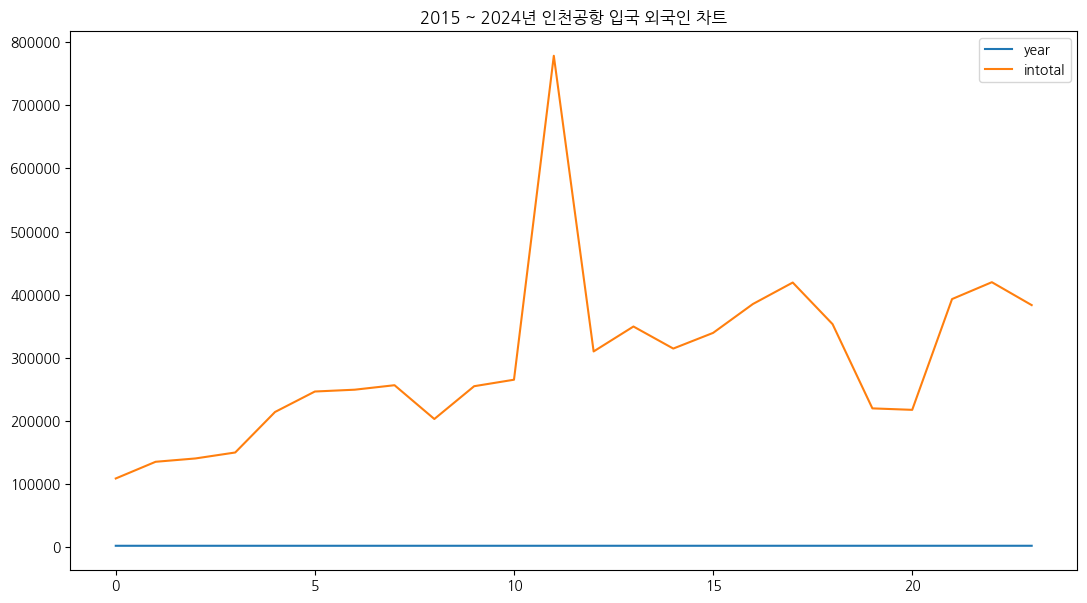

In [9]:
ex2_in.plot(figsize=(13,7),title="2015 ~ 2024년 인천공항 입국 외국인 차트")

<Axes: title={'center': '2015 ~ 2024년 인천공항 출국 외국인 차트'}>

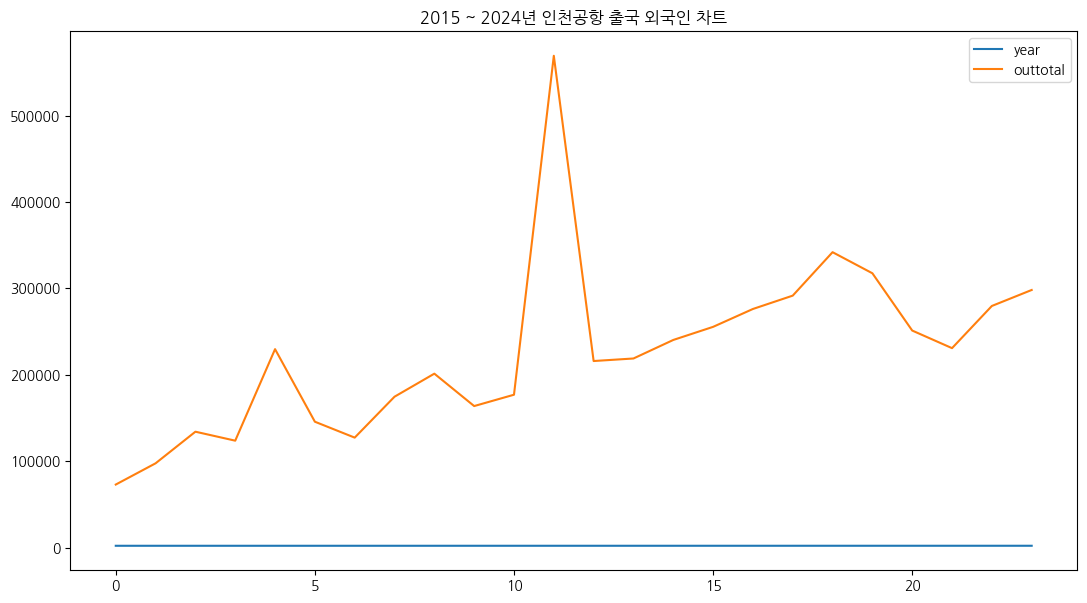

In [10]:
ex2_out.plot(figsize=(13,7),title="2015 ~ 2024년 인천공항 출국 외국인 차트")

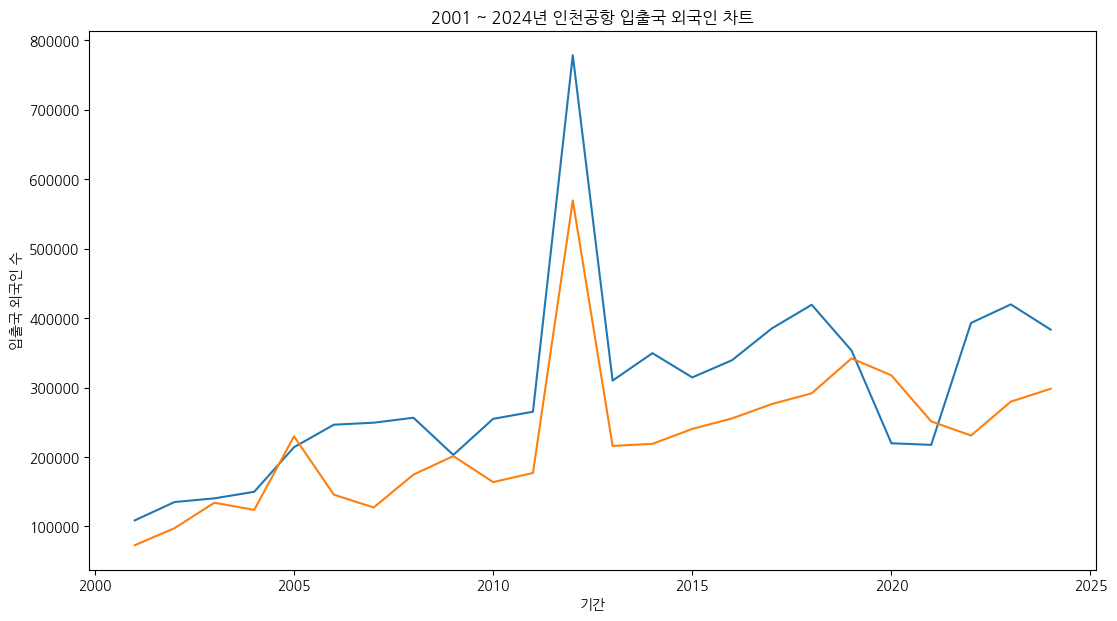

In [11]:
# ex2_in , ex2_out
plt.figure(figsize=(13,7))
plt.plot(ex2_in['year'],ex2_in['intotal'])
plt.plot(ex2_out['year'],ex2_out['outtotal'])
plt.title("2001 ~ 2024년 인천공항 입출국 외국인 차트")
plt.xlabel("기간")
plt.ylabel("입출국 외국인 수")
plt.savefig("./인천공항입출국차트.png")
plt.show()

In [12]:
# !pip install prophet
# !pip install plotly

In [13]:
from prophet import Prophet # time 은 ds, value 는 y 전처리필요

In [20]:
pro_data = ex2_in.copy()
pro_data['year'] = pd.to_datetime(pro_data['year'], format="%Y")
pro_data.rename(columns={'year':'ds','intotal':'y'}, inplace=True )
pro_data.head()

,ds,y
0,2001-01-01,108662
1,2002-01-01,135099
2,2003-01-01,140375
3,2004-01-01,149826
4,2005-01-01,214051


In [21]:
m = Prophet()
m.fit(pro_data)

02:25:37 - cmdstanpy - INFO - Chain [1] start processing
02:25:37 - cmdstanpy - INFO - Chain [1] done processing


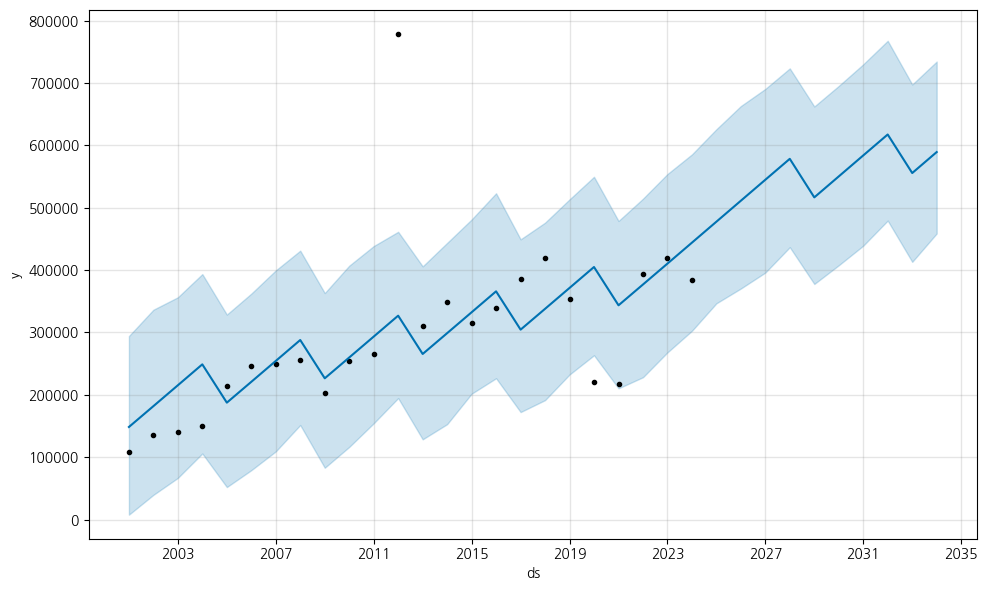

In [25]:
future = m.make_future_dataframe(periods=10, freq='Y')
forecast = m.predict(future)
fig1 = m.plot(forecast)
plt.savefig("./인천공항입출국차트(10년예측).png")
plt.show()

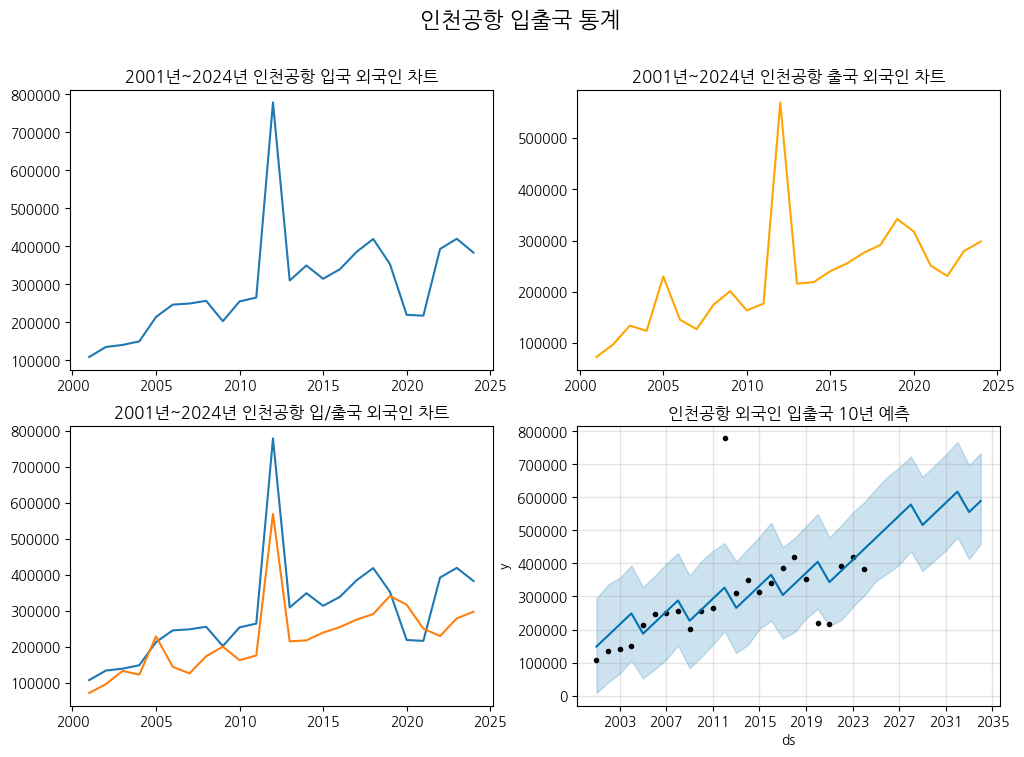

In [54]:
fig , ax = plt.subplots(2,2,figsize=(12,8))
ax[0,0].plot(ex2_in['year'],ex2_in['intotal'])
ax[0,1].plot(ex2_out['year'],ex2_out['outtotal'], color='orange')
ax[1,0].plot(ex2_in['year'],ex2_in['intotal'])
ax[1,0].plot(ex2_out['year'],ex2_out['outtotal'])
m.plot(forecast, ax=ax[1,1])

fig.suptitle('인천공항 입출국 통계', fontsize=16)
ax[0,0].set_title("2001년~2024년 인천공항 입국 외국인 차트")
ax[0,1].set_title("2001년~2024년 인천공항 출국 외국인 차트")
ax[1,0].set_title("2001년~2024년 인천공항 입/출국 외국인 차트")
ax[1,1].set_title("인천공항 외국인 입출국 10년 예측")
plt.savefig('인천공항입출국통계total.png')
plt.show()